<a href="https://colab.research.google.com/github/jalljua1978/algoritmos_optimizacion_VIU/blob/main/JAVIER_LLUESMA_JUAN_Trabajo_Pr%C3%A1ctico_Configuraci%C3%B3n_de_Tribunales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Javier Lluesma Juan  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/1cmg_t7JnXTs3Ik6jD_qBuQTItzYszH2S#scrollTo=_Hyx-QwZzscC <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:(copiar enunciado)

#**Configuración de Tribunales**







                                        

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

<br><br>
**Representación del espacio de soluciones**


El espacio de soluciones se representa como el conjunto de todas las planificaciones posibles de los 15 tribunales. Cada solución completa se codifica como un cromosoma formado por 15 genes, uno por tribunal.
A su vez, cada gen contiene la información necesaria para definir un tribunal: el slot temporal asignado (día y hora) y los tres profesores que desempeñan los roles de Presidente, Secretario y Vocal. Esta representación es coherente con el problema, ya que el enunciado exige precisamente construir 15 tribunales, cada uno con esos tres roles, respetando disponibilidad y compatibilidad de funciones.

De forma más concreta, cada gen puede expresarse como una tupla del tipo:

*(slot,Presidente,Secretario,Vocal)*.

Y una solución completa sería:

[g1​,g2​,…,g15​].

donde cada $g_i$, representa uno de los 15 tribunales. Esta forma de codificación encaja con lo explicado en el tema de algoritmos genéticos, donde se indica que una de las primeras decisiones del diseño consiste en definir una representación adecuada de las soluciones, ya que los operadores de cruce y mutación deben ser consistentes con dicha representación.
<br><br>

**Función objetivo**

La función objetivo lo que intenta es repartir los tribunales de la forma más equilibrada posible entre los profesores. Es decir, evitar que haya profesores con muchísimos tribunales y otros con casi ninguno, que es justo lo que pide el enunciado.

En total hay 15 tribunales y cada uno necesita 3 profesores, así que tenemos:

15 × 3 = 45 asignaciones

Como participan 10 profesores, lo ideal sería que cada uno tuviera más o menos la misma carga. Si repartimos, sale una media de:

45 / 10 = 4,5 tribunales por profesor

A partir de ahí, lo que se hace es mirar cuántos tribunales tiene cada profesor (np) y ver cuánto se aleja de esa media de 4,5. La función objetivo básicamente suma todas esas diferencias (al cuadrado) para todos los profesores.

Es decir, cuanto más se desvíe un profesor de ese 4,5 (ya sea por tener demasiados o muy pocos tribunales), peor será la solución. Por eso, el objetivo es minimizar ese valor, esto es, que todos estén lo más cerca posible de la media.

En el contexto de algoritmos genéticos, esta función actúa como la función de evaluación o fitness, que es la que mide qué tan buena es cada solución.
<br><br>

**Implementación de las restricciones**

Las restricciones se implementan mediante un sistema de penalizaciones dentro de la función fitness, siguiendo lo explicado en el tema de algoritmos genéticos, donde se indica expresamente que las restricciones del problema pueden modelarse como penalizaciones aplicadas a la función de evaluación.

En este problema, las restricciones que deben cumplirse son las siguientes:

*   Cada tribunal debe tener exactamente tres profesores, uno en cada rol: Presidente, Secretario y Vocal.
*   Un profesor solo puede ocupar un rol para el que esté habilitado según la tabla de roles del enunciado.
*   Un profesor solo puede ser asignado a un tribunal en una franja en la que tenga disponibilidad.
*   Un mismo profesor no puede participar en dos tribunales a la misma fecha y hora.
*   Dentro de un mismo tribunal no puede repetirse un profesor en varios roles.

Para implementar esto, a cada solución se le calcula primero el coste de equilibrio, y después se le añaden penalizaciones grandes si incumple alguna restricción. Por ejemplo:

*   Penalización si un profesor no está disponible en el slot asignado.
*   Penalización si un profesor ocupa un rol no permitido.
*   Penalización si aparece repetido dentro del mismo tribunal.
*   Penalización si está convocado en dos tribunales simultáneos.


De este modo, la función total queda como:

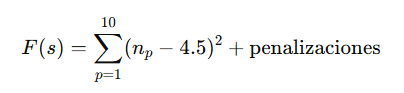


Así, las soluciones inviables obtienen un valor mucho peor que las factibles, y el algoritmo genético tiende a favorecer las soluciones que respetan las restricciones y, además, equilibran mejor la carga entre profesores. Esto encaja exactamente con el enfoque del temario, en el que la fitness guía la selección de los individuos más aptos de la población.



#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

El problema de generación de tribunales es un problema de optimización combinatoria con restricciones, en el que se deben asignar profesores a tribunales respetando múltiples condiciones (disponibilidad, roles, no solapamientos, etc.). Este tipo de problemas se caracteriza por tener un espacio de soluciones muy grande, lo que hace inviable una resolución mediante búsqueda exhaustiva.<br><br>

**Espacio de soluciones**

Cada solución consiste en asignar:

*   Un slot temporal a cada uno de los 15 tribunales.
*   Una terna de profesores (Presidente, Secretario y Vocal) para cada tribunal.

Si consideramos:
*   Aproximadamente S = 35 posibles slots (5 días x 7 horas).
*   Una terna de profesores (Presidente, Secretario y Vocal) para cada tribunal.

entonces, para cada tribunal:
*   S posibles elecciones de slot.
*   Aproximadamente P·(P-1)·(P-2) formas de asignar 3 profesores diferentes con roles (permutaciones sin repetición).

Por tanto, el número de configuraciones posibles para un tribunal es del orden de: S·P·(P-1)·(P-2), y para los 15 tribunales: $(A⋅P⋅(P-1)⋅(P-2))^{15}$.

Si sustituimos los valores: $(35⋅10⋅9⋅8)^{15}$ = $25.200^{15}$.

Este número es extremadamente grande (del orden de $10^{66}$), lo que confirma que el espacio de soluciones crece de forma **exponencial**.<br><br>

**Orden de complejidad**

Si se intentara resolver el problema mediante búsqueda exhaustiva, el coste sería: ($(S⋅$P^3$)^T$)
donde:

S es el número de slots.

*   S es el número de slots.
*   P el número de profesores.
*   T el número de tribunales (15).

Por tanto, el problema es computacionalmente inabordable mediante métodos exactos para tamaños moderados, lo que justifica el uso de técnicas metaheurísticas.<br><br>


**Complejidad del algoritmo utilizado**

En este trabajo se utiliza un algoritmo genético, cuya complejidad depende de:

*   P: tamaño de la población.
*   G: número de generaciones.
*   T: tamaño del cromosoma (número de tribunales).

Cada evaluación de un individuo requiere recorrer todos los tribunales, por lo que tiene coste T. Como en cada generación se evalúan aproximadamente P individuos, el coste total es: (G⋅P⋅T).

Dado que T = 15 es constante, en la práctica la complejidad depende principalmente de G y P, lo que hace que el algoritmo sea polinómico y controlable, a diferencia de la búsqueda exhaustiva.



#Diseño
- ¿Que técnica utilizo? ¿Por qué?

Para resolver el problema se utiliza un algoritmo genético, que pertenece a la categoría de metaheurísticas basadas en poblaciones, y estudiado en la asignatura. Este tipo de técnicas está inspirado en los procesos de evolución natural y se basa en la idea de hacer evolucionar un conjunto de soluciones mediante operadores como selección, cruce y mutación.<br><br>
**Justificación de la técnica**

Se ha elegido un algoritmo genético porque el problema tiene muchas combinaciones posibles y muchas restricciones, lo que hace que probar todas las soluciones sea inviable.

Este tipo de algoritmos funciona bien en estos casos porque, en lugar de buscar todas las opciones, trabaja con un conjunto de soluciones y va mejorándolas poco a poco mediante selección, cruce y mutación.

Además, permite tener en cuenta tanto el equilibrio entre profesores como las restricciones (disponibilidad, roles, etc.) dentro de la misma función fitness, lo que facilita encontrar soluciones válidas y de buena calidad.

Por último, combina exploración y mejora de soluciones, lo que ayuda a encontrar buenas soluciones sin necesidad de conocer de antemano cuál es la mejor.



In [1]:
# En esta celda importo las librerías que voy a necesitar.
# Son librerías básicas para manejar datos, hacer copias, contar elementos y dibujar gráficos.

import random
import copy
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Aquí defino los datos básicos del problema:
# - profesores
# - días
# - horas
# - slots posibles
# - número de tribunales

PROFESSORS = ["RRD", "QYV", "LHL", "HLC", "MSB", "PMQ", "QWF", "EBB", "IOE", "IOA"]

DAYS = [15, 16, 17, 18, 19]
HOURS = [15, 16, 17, 18, 19, 20, 21]

SLOTS = [(d, h) for d in DAYS for h in HOURS]

NUM_TRIBUNALS = 15

print("Profesores:", PROFESSORS)
print("Número de slots:", len(SLOTS))
print("Número de tribunales:", NUM_TRIBUNALS)

Profesores: ['RRD', 'QYV', 'LHL', 'HLC', 'MSB', 'PMQ', 'QWF', 'EBB', 'IOE', 'IOA']
Número de slots: 35
Número de tribunales: 15


In [3]:
# En esta celda indico qué roles puede hacer cada profesor.
# P = Presidente
# S = Secretario
# V = Vocal

ALLOWED_ROLES = {
    "RRD": {"P", "S", "V"},
    "QYV": {"P", "S", "V"},
    "LHL": {"P", "V"},
    "HLC": {"S", "V"},
    "MSB": {"P", "S", "V"},
    "PMQ": {"P", "S", "V"},
    "QWF": {"S", "V"},
    "EBB": {"S", "V"},
    "IOE": {"P", "S", "V"},
    "IOA": {"P", "S", "V"},
}

for p, roles in ALLOWED_ROLES.items():
    print(p, "->", sorted(list(roles)))

RRD -> ['P', 'S', 'V']
QYV -> ['P', 'S', 'V']
LHL -> ['P', 'V']
HLC -> ['S', 'V']
MSB -> ['P', 'S', 'V']
PMQ -> ['P', 'S', 'V']
QWF -> ['S', 'V']
EBB -> ['S', 'V']
IOE -> ['P', 'S', 'V']
IOA -> ['P', 'S', 'V']


In [4]:
# Aquí cargo la disponibilidad de cada profesor.
# La estructura es:
# availability_matrix["RRD"][(15,16)] = 1   si está disponible
# availability_matrix["RRD"][(15,16)] = 0   si no está disponible

availability_matrix = {
    "RRD": {
        (15,15):0, (15,16):1, (15,17):1, (15,18):1, (15,19):0, (15,20):1, (15,21):1,
        (16,15):1, (16,16):0, (16,17):1, (16,18):1, (16,19):1, (16,20):1, (16,21):1,
        (17,15):1, (17,16):1, (17,17):0, (17,18):0, (17,19):1, (17,20):0, (17,21):1,
        (18,15):0, (18,16):1, (18,17):1, (18,18):1, (18,19):1, (18,20):1, (18,21):1,
        (19,15):1, (19,16):1, (19,17):1, (19,18):1, (19,19):1, (19,20):0, (19,21):0,
    },
    "QYV": {
        (15,15):1, (15,16):1, (15,17):1, (15,18):1, (15,19):0, (15,20):0, (15,21):0,
        (16,15):0, (16,16):1, (16,17):1, (16,18):1, (16,19):1, (16,20):0, (16,21):0,
        (17,15):1, (17,16):0, (17,17):0, (17,18):1, (17,19):1, (17,20):1, (17,21):0,
        (18,15):1, (18,16):1, (18,17):1, (18,18):1, (18,19):1, (18,20):1, (18,21):1,
        (19,15):1, (19,16):1, (19,17):1, (19,18):1, (19,19):1, (19,20):1, (19,21):1,
    },
    "LHL": {
        (15,15):0, (15,16):0, (15,17):1, (15,18):1, (15,19):0, (15,20):1, (15,21):1,
        (16,15):1, (16,16):1, (16,17):1, (16,18):0, (16,19):0, (16,20):1, (16,21):1,
        (17,15):1, (17,16):1, (17,17):1, (17,18):1, (17,19):1, (17,20):1, (17,21):1,
        (18,15):1, (18,16):0, (18,17):1, (18,18):1, (18,19):1, (18,20):0, (18,21):1,
        (19,15):0, (19,16):1, (19,17):1, (19,18):0, (19,19):1, (19,20):0, (19,21):1,
    },
    "HLC": {
        (15,15):1, (15,16):0, (15,17):1, (15,18):0, (15,19):1, (15,20):1, (15,21):0,
        (16,15):1, (16,16):0, (16,17):0, (16,18):1, (16,19):1, (16,20):1, (16,21):1,
        (17,15):0, (17,16):0, (17,17):1, (17,18):1, (17,19):1, (17,20):1, (17,21):1,
        (18,15):1, (18,16):0, (18,17):1, (18,18):1, (18,19):0, (18,20):1, (18,21):1,
        (19,15):1, (19,16):1, (19,17):1, (19,18):1, (19,19):1, (19,20):1, (19,21):0,
    },
    "MSB": {
        (15,15):1, (15,16):1, (15,17):0, (15,18):1, (15,19):0, (15,20):1, (15,21):1,
        (16,15):1, (16,16):1, (16,17):1, (16,18):0, (16,19):1, (16,20):1, (16,21):1,
        (17,15):1, (17,16):0, (17,17):1, (17,18):1, (17,19):0, (17,20):1, (17,21):1,
        (18,15):0, (18,16):1, (18,17):1, (18,18):1, (18,19):0, (18,20):1, (18,21):1,
        (19,15):1, (19,16):0, (19,17):1, (19,18):1, (19,19):1, (19,20):1, (19,21):0,
    },
    "PMQ": {
        (15,15):1, (15,16):1, (15,17):1, (15,18):1, (15,19):1, (15,20):0, (15,21):0,
        (16,15):1, (16,16):1, (16,17):1, (16,18):1, (16,19):1, (16,20):1, (16,21):1,
        (17,15):1, (17,16):1, (17,17):0, (17,18):0, (17,19):1, (17,20):1, (17,21):1,
        (18,15):1, (18,16):1, (18,17):1, (18,18):0, (18,19):0, (18,20):1, (18,21):1,
        (19,15):1, (19,16):1, (19,17):1, (19,18):0, (19,19):1, (19,20):0, (19,21):1,
    },
    "QWF": {
        (15,15):0, (15,16):1, (15,17):1, (15,18):1, (15,19):1, (15,20):1, (15,21):1,
        (16,15):1, (16,16):1, (16,17):0, (16,18):1, (16,19):1, (16,20):0, (16,21):1,
        (17,15):0, (17,16):0, (17,17):1, (17,18):1, (17,19):0, (17,20):0, (17,21):1,
        (18,15):1, (18,16):0, (18,17):0, (18,18):0, (18,19):0, (18,20):1, (18,21):1,
        (19,15):1, (19,16):1, (19,17):1, (19,18):1, (19,19):1, (19,20):0, (19,21):1,
    },
    "EBB": {
        (15,15):1, (15,16):1, (15,17):1, (15,18):1, (15,19):1, (15,20):0, (15,21):0,
        (16,15):1, (16,16):1, (16,17):0, (16,18):1, (16,19):1, (16,20):1, (16,21):0,
        (17,15):1, (17,16):1, (17,17):1, (17,18):0, (17,19):0, (17,20):1, (17,21):1,
        (18,15):0, (18,16):1, (18,17):1, (18,18):1, (18,19):1, (18,20):1, (18,21):1,
        (19,15):0, (19,16):1, (19,17):1, (19,18):1, (19,19):0, (19,20):1, (19,21):0,
    },
    "IOE": {
        (15,15):1, (15,16):0, (15,17):1, (15,18):1, (15,19):0, (15,20):1, (15,21):0,
        (16,15):0, (16,16):1, (16,17):1, (16,18):1, (16,19):1, (16,20):1, (16,21):1,
        (17,15):1, (17,16):1, (17,17):0, (17,18):0, (17,19):0, (17,20):1, (17,21):1,
        (18,15):1, (18,16):1, (18,17):1, (18,18):1, (18,19):1, (18,20):1, (18,21):0,
        (19,15):1, (19,16):0, (19,17):1, (19,18):1, (19,19):1, (19,20):1, (19,21):1,
    },
    "IOA": {
        (15,15):1, (15,16):1, (15,17):0, (15,18):1, (15,19):1, (15,20):0, (15,21):1,
        (16,15):1, (16,16):0, (16,17):0, (16,18):0, (16,19):0, (16,20):0, (16,21):1,
        (17,15):1, (17,16):1, (17,17):0, (17,18):0, (17,19):1, (17,20):1, (17,21):1,
        (18,15):1, (18,16):0, (18,17):0, (18,18):1, (18,19):1, (18,20):1, (18,21):1,
        (19,15):1, (19,16):1, (19,17):1, (19,18):0, (19,19):0, (19,20):0, (19,21):1,
    },
}

In [5]:
# Aquí transformo la disponibilidad a un formato más cómodo para usarlo en el algoritmo.
# Así luego puedo consultar fácilmente si un profesor está disponible en un slot concreto.

availability = {}
for prof in PROFESSORS:
    for slot in SLOTS:
        availability[(prof, slot)] = availability_matrix[prof][slot]

print("Número total de entradas de disponibilidad:", len(availability))
print("Ejemplo:", availability[("RRD", (15, 16))])

Número total de entradas de disponibilidad: 350
Ejemplo: 1


In [6]:
# Esta celda solo sirve para ver la tabla de disponibilidad de forma más cómoda.

availability_df = pd.DataFrame.from_dict(availability_matrix, orient="index")
availability_df = availability_df[[ (d,h) for d in DAYS for h in HOURS ]]
availability_df

15                   16        ... 18       19                  
    15 16 17 18 19 20 21 15 16 17  ... 19 20 21 15 16 17 18 19 20 21
RRD  0  1  1  1  0  1  1  1  0  1  ...  1  1  1  1  1  1  1  1  0  0
QYV  1  1  1  1  0  0  0  0  1  1  ...  1  1  1  1  1  1  1  1  1  1
LHL  0  0  1  1  0  1  1  1  1  1  ...  1  0  1  0  1  1  0  1  0  1
HLC  1  0  1  0  1  1  0  1  0  0  ...  0  1  1  1  1  1  1  1  1  0
MSB  1  1  0  1  0  1  1  1  1  1  ...  0  1  1  1  0  1  1  1  1  0
PMQ  1  1  1  1  1  0  0  1  1  1  ...  0  1  1  1  1  1  0  1  0  1
QWF  0  1  1  1  1  1  1  1  1  0  ...  0  1  1  1  1  1  1  1  0  1
EBB  1  1  1  1  1  0  0  1  1  0  ...  1  1  1  0  1  1  1  0  1  0
IOE  1  0  1  1  0  1  0  0  1  1  ...  1  1  0  1  0  1  1  1  1  1
IOA  1  1  0  1  1  0  1  1  0  0  ...  1  1  1  1  1  1  0  0  0  1

[10 rows x 35 columns]

In [7]:
# En esta parte empiezo a construir las piezas del algoritmo genético.
# Primero necesito funciones para crear profesores válidos y tribunales aleatorios.

def random_professor_for_role(role, slot, used=None):
    if used is None:
        used = set()

    candidates = [
        p for p in PROFESSORS
        if role in ALLOWED_ROLES[p]
        and availability[(p, slot)] == 1
        and p not in used
    ]

    if not candidates:
        return None

    return random.choice(candidates)


def create_random_court():
    slot = random.choice(SLOTS)
    used = set()

    president = random_professor_for_role("P", slot, used)
    if president is not None:
        used.add(president)

    secretary = random_professor_for_role("S", slot, used)
    if secretary is not None:
        used.add(secretary)

    vocal = random_professor_for_role("V", slot, used)

    return {
        "slot": slot,
        "P": president,
        "S": secretary,
        "V": vocal
    }


def create_individual():
    return [create_random_court() for _ in range(NUM_TRIBUNALS)]


def create_population(size):
    return [create_individual() for _ in range(size)]

In [8]:
# Esta es una de las partes más importantes.
# Aquí mido si una solución es buena o mala.
#
# La idea es:
# - penalizar errores o restricciones incumplidas
# - premiar el equilibrio entre profesores

PENALTY_UNAVAILABLE = 1000
PENALTY_INVALID_ROLE = 1000
PENALTY_DUPLICATE_IN_COURT = 1500
PENALTY_OVERLAP = 2000
PENALTY_MISSING = 2500


def evaluate_individual(individual):
    penalties = 0
    load = Counter()
    occupied = defaultdict(list)

    for court in individual:
        slot = court["slot"]
        assigned = [court["P"], court["S"], court["V"]]

        # Penalizo si falta alguien
        for role in ["P", "S", "V"]:
            if court[role] is None:
                penalties += PENALTY_MISSING

        # Penalizo si se repite un profesor dentro del tribunal
        non_null = [x for x in assigned if x is not None]
        if len(non_null) != len(set(non_null)):
            penalties += PENALTY_DUPLICATE_IN_COURT

        # Compruebo rol y disponibilidad
        for role in ["P", "S", "V"]:
            prof = court[role]

            if prof is None:
                continue

            if availability[(prof, slot)] != 1:
                penalties += PENALTY_UNAVAILABLE

            if role not in ALLOWED_ROLES[prof]:
                penalties += PENALTY_INVALID_ROLE

            load[prof] += 1
            occupied[slot].append(prof)

    # Penalizo solapamientos
    for slot, profs in occupied.items():
        counts = Counter(profs)
        for prof, c in counts.items():
            if c > 1:
                penalties += (c - 1) * PENALTY_OVERLAP

    # Parte de equilibrio
    mean_load = (NUM_TRIBUNALS * 3) / len(PROFESSORS)   # 45 / 10 = 4.5
    imbalance = 0.0

    for p in PROFESSORS:
        imbalance += (load[p] - mean_load) ** 2

    cost = imbalance + penalties

    # Cuanto menor sea el coste, mejor.
    # Convierto eso en fitness positiva para el algoritmo genético.
    fitness = 1 / (1 + cost)

    return {
        "fitness": fitness,
        "cost": cost,
        "imbalance": imbalance,
        "penalties": penalties,
        "load": load
    }

In [9]:
# Después del cruce y la mutación pueden aparecer soluciones raras o inválidas.
# Por eso añado una pequeña fase de reparación para intentar arreglarlas.

def repair_individual(individual):
    repaired = copy.deepcopy(individual)

    # Completar o corregir profesores inválidos
    for court in repaired:
        slot = court["slot"]

        for role in ["P", "S", "V"]:
            prof = court[role]

            invalid = (
                prof is None
                or availability[(prof, slot)] != 1
                or role not in ALLOWED_ROLES[prof]
            )

            if invalid:
                used = {
                    court[r] for r in ["P", "S", "V"]
                    if r != role and court[r] is not None
                }
                candidate = random_professor_for_role(role, slot, used)
                court[role] = candidate

    # Evitar repetidos dentro del mismo tribunal
    for court in repaired:
        slot = court["slot"]
        seen = set()

        for role in ["P", "S", "V"]:
            prof = court[role]

            if prof is None or prof in seen:
                used = {
                    court[r] for r in ["P", "S", "V"]
                    if r != role and court[r] is not None
                }
                court[role] = random_professor_for_role(role, slot, used)

            if court[role] is not None:
                seen.add(court[role])

    return repaired

In [10]:
# En esta celda defino cómo se seleccionan los padres.
# Voy a usar selección por torneo porque es simple y funciona bien.

def tournament_selection(population, k=3):
    sampled = random.sample(population, k)
    sampled.sort(key=lambda ind: evaluate_individual(ind)["cost"])
    return copy.deepcopy(sampled[0])

In [11]:
# El cruce mezcla dos soluciones para generar descendientes.
# Voy a usar cruce en un punto:
# una parte del cromosoma viene de un padre y la otra del otro.

def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() > crossover_rate:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)

    point = random.randint(1, NUM_TRIBUNALS - 1)

    child1 = copy.deepcopy(parent1[:point] + parent2[point:])
    child2 = copy.deepcopy(parent2[:point] + parent1[point:])

    return child1, child2

In [12]:
# La mutación sirve para introducir variedad.
# Así evitamos que el algoritmo se quede estancado demasiado pronto.

def mutate_court(court):
    new_court = copy.deepcopy(court)
    mutation_type = random.choice(["slot", "professor", "swap_roles"])

    if mutation_type == "slot":
        new_court["slot"] = random.choice(SLOTS)

    elif mutation_type == "professor":
        role = random.choice(["P", "S", "V"])
        used = {
            new_court[r] for r in ["P", "S", "V"]
            if r != role and new_court[r] is not None
        }
        candidate = random_professor_for_role(role, new_court["slot"], used)
        new_court[role] = candidate

    elif mutation_type == "swap_roles":
        r1, r2 = random.sample(["P", "S", "V"], 2)
        p1, p2 = new_court[r1], new_court[r2]

        if p1 is not None and p2 is not None:
            if (r2 in ALLOWED_ROLES[p1]) and (r1 in ALLOWED_ROLES[p2]):
                new_court[r1], new_court[r2] = p2, p1

    return new_court


def mutate(individual, mutation_rate=0.15):
    mutated = copy.deepcopy(individual)

    for i in range(NUM_TRIBUNALS):
        if random.random() < mutation_rate:
            mutated[i] = mutate_court(mutated[i])

    return mutated

In [13]:
# Aquí junto todo.
# El algoritmo:
# - crea población inicial
# - evalúa
# - selecciona
# - cruza
# - muta
# - repite durante varias generaciones

def genetic_algorithm(
    population_size=80,
    generations=300,
    crossover_rate=0.8,
    mutation_rate=0.15,
    elitism=2,
    tournament_k=3,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)

    population = create_population(population_size)
    population = [repair_individual(ind) for ind in population]

    best_history = []
    avg_history = []

    best_individual = None
    best_eval = None

    for gen in range(generations):
        evaluated = [(ind, evaluate_individual(ind)) for ind in population]
        evaluated.sort(key=lambda x: x[1]["cost"])

        current_best, current_best_eval = evaluated[0]
        current_avg = sum(ev["cost"] for _, ev in evaluated) / len(evaluated)

        best_history.append(current_best_eval["cost"])
        avg_history.append(current_avg)

        if best_eval is None or current_best_eval["cost"] < best_eval["cost"]:
            best_individual = copy.deepcopy(current_best)
            best_eval = current_best_eval

        new_population = []

        # Elitismo: conservo los mejores
        for i in range(elitism):
            new_population.append(copy.deepcopy(evaluated[i][0]))

        # Genero el resto de la nueva población
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_k)
            parent2 = tournament_selection(population, tournament_k)

            child1, child2 = crossover(parent1, parent2, crossover_rate)

            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            child1 = repair_individual(child1)
            child2 = repair_individual(child2)

            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_individual, best_eval, best_history, avg_history

In [14]:
# Aquí lanzo el algoritmo genético con unos parámetros razonables.

best_individual, best_eval, best_history, avg_history = genetic_algorithm(
    population_size=80,
    generations=300,
    crossover_rate=0.8,
    mutation_rate=0.15,
    elitism=2,
    tournament_k=3,
    seed=42
)

print("Mejor coste encontrado:", best_eval["cost"])
print("Penalizaciones:", best_eval["penalties"])
print("Desequilibrio:", best_eval["imbalance"])

print("\nCarga por profesor:")
for p in PROFESSORS:
    print(p, "->", best_eval["load"][p])

Mejor coste encontrado: 2.5
Penalizaciones: 0
Desequilibrio: 2.5

Carga por profesor:
RRD -> 4
QYV -> 5
LHL -> 5
HLC -> 4
MSB -> 5
PMQ -> 5
QWF -> 4
EBB -> 4
IOE -> 5
IOA -> 4


In [15]:
# Esta celda sirve para mostrar el resultado final de forma clara.

def individual_to_dataframe(individual):
    rows = []

    for i, court in enumerate(individual, start=1):
        day, hour = court["slot"]

        rows.append({
            "Tribunal": i,
            "Día": day,
            "Hora": hour,
            "Presidente": court["P"],
            "Secretario": court["S"],
            "Vocal": court["V"],
        })

    df = pd.DataFrame(rows)
    return df.sort_values(["Día", "Hora", "Tribunal"]).reset_index(drop=True)


solution_df = individual_to_dataframe(best_individual)
solution_df

,Tribunal,Día,Hora,Presidente,Secretario,Vocal
0,1,15,15,IOE,HLC,MSB
1,7,15,18,QYV,QWF,LHL
2,4,15,19,IOA,PMQ,QWF
3,9,16,17,LHL,MSB,PMQ
4,14,16,18,QYV,IOE,HLC
5,13,16,21,RRD,MSB,QWF
6,6,17,15,LHL,RRD,PMQ
7,12,17,18,MSB,QYV,HLC
8,15,17,20,IOA,HLC,PMQ
9,11,17,21,RRD,IOA,LHL


In [16]:
# Aquí compruebo si la solución final cumple bien las restricciones.
# Esto viene muy bien para demostrar que la solución es válida.

def verify_solution(individual):
    errors = []
    slot_prof = defaultdict(list)

    for idx, court in enumerate(individual, start=1):
        slot = court["slot"]
        assigned = [court["P"], court["S"], court["V"]]

        if None in assigned:
            errors.append(f"Tribunal {idx}: hay roles vacíos")

        if len([x for x in assigned if x is not None]) != len(set([x for x in assigned if x is not None])):
            errors.append(f"Tribunal {idx}: hay profesores repetidos dentro del tribunal")

        for role in ["P", "S", "V"]:
            prof = court[role]

            if prof is None:
                continue

            if availability[(prof, slot)] != 1:
                errors.append(f"Tribunal {idx}: {prof} no está disponible en {slot}")

            if role not in ALLOWED_ROLES[prof]:
                errors.append(f"Tribunal {idx}: {prof} no puede hacer el rol {role}")

            slot_prof[slot].append(prof)

    for slot, profs in slot_prof.items():
        c = Counter(profs)
        for prof, num in c.items():
            if num > 1:
                errors.append(f"Profesor {prof} aparece {num} veces en el slot {slot}")

    if not errors:
        print("Solución válida: no se han encontrado errores.")
    else:
        print("Errores encontrados:")
        for e in errors:
            print("-", e)


verify_solution(best_individual)

Solución válida: no se han encontrado errores.


In [17]:
# En esta celda muestro cuántos tribunales tiene cada profesor.
# Esto ayuda a ver si el reparto es equilibrado.

load_df = pd.DataFrame({
    "Profesor": PROFESSORS,
    "Tribunales asignados": [best_eval["load"][p] for p in PROFESSORS]
}).sort_values("Tribunales asignados", ascending=False).reset_index(drop=True)

load_df

,Profesor,Tribunales asignados
0,QYV,5
1,LHL,5
2,PMQ,5
3,MSB,5
4,IOE,5
5,RRD,4
6,HLC,4
7,QWF,4
8,EBB,4
9,IOA,4


In [19]:
# Esta tabla muestra claramente, para cada tribunal:
# - el día
# - la hora
# - qué profesor actúa como Presidente
# - qué profesor actúa como Secretario
# - qué profesor actúa como Vocal

def individual_to_dataframe(individual):
    rows = []

    for i, court in enumerate(individual, start=1):
        day, hour = court["slot"]

        rows.append({
            "Tribunal": i,
            "Día": day,
            "Hora": hour,
            "Presidente": court["P"],
            "Secretario": court["S"],
            "Vocal": court["V"],
        })

    df = pd.DataFrame(rows)
    return df.sort_values(["Día", "Hora", "Tribunal"]).reset_index(drop=True)

solution_df = individual_to_dataframe(best_individual)
solution_df

,Tribunal,Día,Hora,Presidente,Secretario,Vocal
0,1,15,15,IOE,HLC,MSB
1,7,15,18,QYV,QWF,LHL
2,4,15,19,IOA,PMQ,QWF
3,9,16,17,LHL,MSB,PMQ
4,14,16,18,QYV,IOE,HLC
5,13,16,21,RRD,MSB,QWF
6,6,17,15,LHL,RRD,PMQ
7,12,17,18,MSB,QYV,HLC
8,15,17,20,IOA,HLC,PMQ
9,11,17,21,RRD,IOA,LHL


In [21]:
# Esta tabla sirve para ver, desde el punto de vista de cada profesor,
# en qué tribunales participa y con qué rol.

def professor_participation_table(individual):
    rows = []

    for i, court in enumerate(individual, start=1):
        day, hour = court["slot"]

        rows.append({
            "Profesor": court["P"],
            "Tribunal": i,
            "Día": day,
            "Hora": hour,
            "Rol": "Presidente"
        })

        rows.append({
            "Profesor": court["S"],
            "Tribunal": i,
            "Día": day,
            "Hora": hour,
            "Rol": "Secretario"
        })

        rows.append({
            "Profesor": court["V"],
            "Tribunal": i,
            "Día": day,
            "Hora": hour,
            "Rol": "Vocal"
        })

    df = pd.DataFrame(rows)
    return df.sort_values(["Profesor", "Día", "Hora", "Tribunal"]).reset_index(drop=True)

participation_df = professor_participation_table(best_individual)
participation_df

,Profesor,Tribunal,Día,Hora,Rol
0,EBB,2,18,18,Secretario
1,EBB,8,19,17,Vocal
2,EBB,3,19,18,Secretario
3,EBB,5,19,20,Vocal
4,HLC,1,15,15,Secretario
5,HLC,14,16,18,Vocal
6,HLC,12,17,18,Vocal
7,HLC,15,17,20,Secretario
8,IOA,4,15,19,Presidente
9,IOA,15,17,20,Presidente


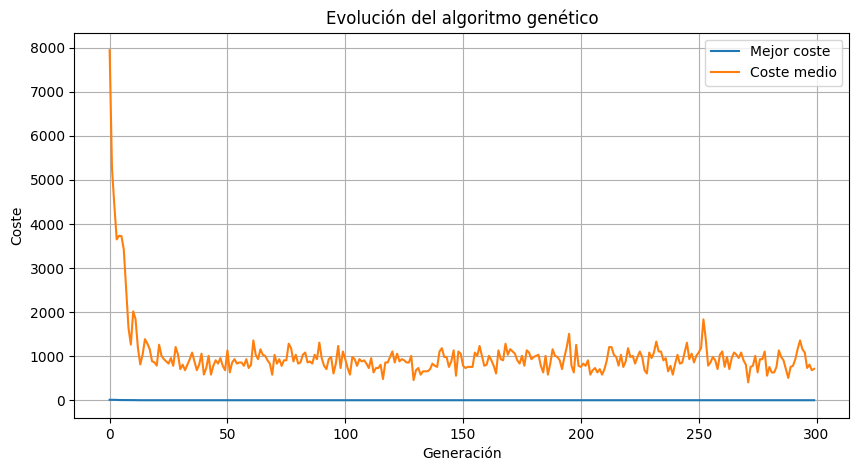

In [18]:
# Aquí dibujo cómo va mejorando el algoritmo con las generaciones.

plt.figure(figsize=(10, 5))
plt.plot(best_history, label="Mejor coste")
plt.plot(avg_history, label="Coste medio")
plt.xlabel("Generación")
plt.ylabel("Coste")
plt.title("Evolución del algoritmo genético")
plt.legend()
plt.grid(True)
plt.show()